# 🏗️ 07-大模型训练优化实践

> 目标：把前面所有优化知识接到**LLM 训练**——FP16/BF16 混合精度、Adam 优化器状态内存、ZeRO 分片。

## §1 三种浮点格式

| 格式 | 总位 | 指数位 | 尾数位 | 最大有限值 | 最小正常值 | 相对精度 |
|------|------|--------|--------|------------|------------|----------|
| FP32 | 32 | 8 | 23 | $\approx 3.4\times10^{38}$ | $1.2\times10^{-38}$ | $\sim10^{-7}$ |
| FP16 | 16 | 5 | 10 | 65504 | $6.1\times10^{-5}$ | $\sim10^{-3}$ |
| BF16 | 16 | 8 | 7 | $\approx 3.4\times10^{38}$ | $1.2\times10^{-38}$ | $\sim10^{-2}$ |

**BF16 = FP32 的指数范围 + 更少的尾数**：梯度/激活很少溢出（LLM 主流）；FP16 范围窄，需要 **loss scaling**。

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 实验 1：FP16 溢出 vs BF16 不溢出（torch 演示） ----------
vals = torch.tensor([1e-4, 1e-3, 0.01, 1.0, 100.0, 5e4])
fp16 = vals.to(torch.float16)
bf16 = vals.to(torch.bfloat16)
fp32 = vals.to(torch.float32)
print('数值       FP32        FP16        BF16')
for v, a, b, c in zip(vals.tolist(), fp32.tolist(), fp16.tolist(), bf16.float().tolist()):
    print(f'{v:8.1e}  {a:12.4e}  {b:12.4e}  {c:12.4e}')
print()
print('FP16 最大有限值:', torch.finfo(torch.float16).max)
print('BF16 最大有限值:', torch.finfo(torch.bfloat16).max)
print('结论: 5e4 在 FP16 中已是 inf；BF16 与 FP32 范围一致')

数值       FP32        FP16        BF16
 1.0e-04    1.0000e-04    1.0002e-04    1.0014e-04
 1.0e-03    1.0000e-03    1.0004e-03    9.9945e-04
 1.0e-02    1.0000e-02    1.0002e-02    1.0010e-02
 1.0e+00    1.0000e+00    1.0000e+00    1.0000e+00
 1.0e+02    1.0000e+02    1.0000e+02    1.0000e+02
 5.0e+04    5.0000e+04    4.9984e+04    4.9920e+04

FP16 最大有限值: 65504.0
BF16 最大有限值: 3.3895313892515355e+38
结论: 5e4 在 FP16 中已是 inf；BF16 与 FP32 范围一致


In [2]:
# ---------- 实验 2：loss scaling 救 FP16 ----------
tiny_grad = 1e-8  # 小于 FP16 最小次正规(≈5.96e-8)，直接存必下溢为 0
fp16_no_scale = np.float16(tiny_grad)          # 直接存 FP16：下溢为 0
scale = 1024.0
fp16_scaled = np.float16(np.float32(tiny_grad) * scale)   # 先在 FP32 放大，再存 FP16
back = np.float32(fp16_scaled) / np.float32(scale)        # 反缩放回 FP32
print(f'原始梯度={tiny_grad:.1e}')
print(f'FP16 直接存={float(fp16_no_scale):.3e}（下溢→0）')
print(f'FP16 缩放存储后反缩放={back:.3e}（保住了）')
assert float(fp16_no_scale) == 0.0 and back > 0
print('loss scaling 原理演示通过')

原始梯度=1.0e-08
FP16 直接存=0.000e+00（下溢→0）
FP16 缩放存储后反缩放=1.001e-08（保住了）
loss scaling 原理演示通过


## §2 混合精度训练流程

1. 参数 FP32 master copy 一份
2. 前向/反向在 FP16/BF16 上做（省显存、加速）
3. 梯度反缩放（FP16）或直接（BF16）后转 FP32
4. 优化器状态与更新在 FP32 master 上做（累加精度）

**为什么 optimizer 状态要 FP32**：Adam 的 $m,v$ 累加必须高精度，否则小更新丢失。

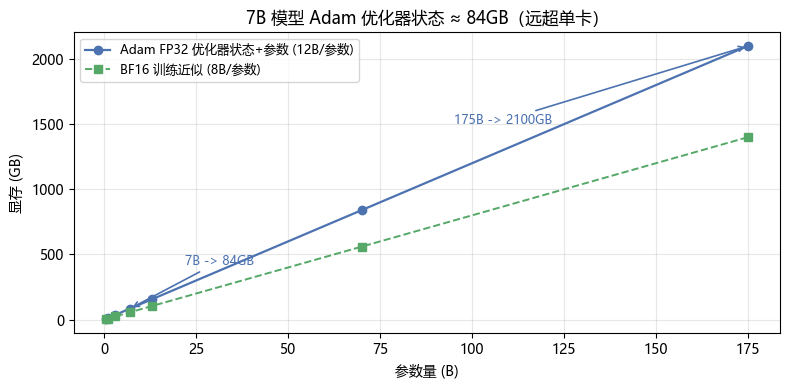

口算：7B × 12B = 84GB 优化器状态+参数（不含激活/梯度）


In [3]:
# ---------- 实验 3：Adam 优化器状态内存分析 ----------
# 参数量 -> 显存（FP32 每个参数：参数4B + m 4B + v 4B = 12B；BF16 参数/梯度可省）
params = np.array([0.5, 1, 3, 7, 13, 70, 175])  # 十亿参数
bytes_per_p = 12  # 参数4 + m4 + v4（FP32 优化器状态）
mem_fp32 = params * bytes_per_p * 1e9 / 1e9     # GB

fig, ax = plt.subplots(figsize=(8, 4.0))
ax.plot(params, mem_fp32, 'o-', color='#4C72B0', lw=1.6, label='Adam FP32 优化器状态+参数 (12B/参数)')
ax.plot(params, params * 8, 's--', color='#55A868', lw=1.4, label='BF16 训练近似 (8B/参数)')
# 只标注两个关键点（避免左侧 x 密集导致标注重叠）
ax.annotate('7B -> 84GB', xy=(7, 84), xytext=(22, 420), fontsize=9, color='#4C72B0',
            arrowprops=dict(arrowstyle='->', color='#4C72B0', lw=1.2))
ax.annotate('175B -> 2100GB', xy=(175, 2100), xytext=(95, 1500), fontsize=9, color='#4C72B0',
            arrowprops=dict(arrowstyle='->', color='#4C72B0', lw=1.2))
ax.set_xlabel('参数量 (B)'); ax.set_ylabel('显存 (GB)')
ax.set_title('7B 模型 Adam 优化器状态 ≈ 84GB（远超单卡）', fontsize=12)
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()
print('口算：7B × 12B = 84GB 优化器状态+参数（不含激活/梯度）')

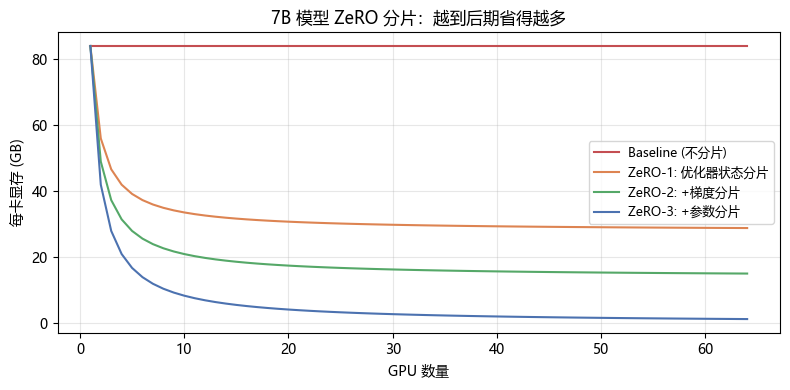

8 卡 ZeRO-3: 10.5GB/卡 vs Baseline 84.0GB


In [4]:
# ---------- 实验 4：ZeRO 分片内存曲线 ----------
# ZeRO-1/2/3：分别把 优化器状态 / +梯度 / +参数 分片到 N 卡
N = np.arange(1, 65)
B = 7e9 * 12 / 1e9   # 7B FP32 全量 GB
def zero_mem(stage, n):
    base = B  # 全量（未分片）
    if stage == 1:  # 只分优化器状态(8B/p)，参数+梯度(4B/p) 每卡都有
        return 7 * 8 / n + 7 * 4
    if stage == 2:  # 优化器状态+梯度(10B/p) 分片
        return 7 * 10 / n + 7 * 2
    if stage == 3:  # 全部(12B/p) 分片
        return 7 * 12 / n
    return base

fig, ax = plt.subplots(figsize=(8, 4.0))
for st, col, lab in [(0, '#C44E52', 'Baseline (不分片)'),
                     (1, '#DD8452', 'ZeRO-1: 优化器状态分片'),
                     (2, '#55A868', 'ZeRO-2: +梯度分片'),
                     (3, '#4C72B0', 'ZeRO-3: +参数分片')]:
    if st == 0:
        ax.plot(N, np.full_like(N, B), color=col, lw=1.5, label=lab)
    else:
        ax.plot(N, [zero_mem(st, n) for n in N], color=col, lw=1.5, label=lab)
ax.set_xlabel('GPU 数量'); ax.set_ylabel('每卡显存 (GB)')
ax.set_title('7B 模型 ZeRO 分片：越到后期省得越多', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('8 卡 ZeRO-3: %.1fGB/卡 vs Baseline %.1fGB' % (zero_mem(3, 8), B))

## §3 显存换时间的组合拳

- **梯度累积**：等效大 batch，显存不变（见 05 篇）
- **激活重计算（gradient checkpointing）**：不存中间激活，反向时重算 → 显存 $O(L)$ 变 $O(\sqrt L)$ 量级，代价约 30% 时间
- **ZeRO-offload**：优化器状态 / 梯度挪到 CPU，GPU 显存进一步降
- **流水并行 + 张量并行**：模型切分，配 ZeRO 组成三维并行

## §4 面试速答

- **为什么 BF16 不是 FP16**：指数位 8=FP32，范围不溢出 → 免 loss scaling；尾数少但训练可容忍
- **7B Adam 状态口算**：$7\times10^9\times 12$B $= 84$GB
- **ZeRO 三阶段**：优化器状态 / +梯度 / +参数 依次分片，通信量递增
- **为什么优化器状态必须 FP32**：Adam 累加精度

## §5 自测清单

- [ ] 默写 FP16/BF16 指数位与最大范围
- [ ] 演示 loss scaling（本文实验）
- [ ] 口算 7B Adam 状态显存（84GB）
- [ ] 画出 ZeRO-1/2/3 内存曲线（本文已出图）
- [ ] 说清重计算/offload 换什么、花什么

> 💡 本笔记验收：`08-优化算法/README.md` 验收清单「混合精度 / ZeRO 内存计算」打勾。